In [29]:
import sys, os
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

from src.utils.data_loader import load_splits
from src.utils.config import ISOT_CONFIG

train_df, val_df, test_df = load_splits(ISOT_CONFIG)

Processed dataset for isot already exists. Loading from disk.


In [30]:
# Dataset overview — size and null rates in the raw source
import pandas as pd

raw_true_path = project_root / "data" / "raw" / "isot" / "True.csv"
raw_fake_path = project_root / "data" / "raw" / "isot" / "Fake.csv"
true_df = pd.read_csv(raw_true_path)
fake_df = pd.read_csv(raw_fake_path)

print("=== Raw ISOT Dataset ===")
print(f"True.csv (Real): {len(true_df):,}")
print(f"Fake.csv (Fake): {len(fake_df):,}  ← Fake is majority in raw")
print(f"Total:           {len(true_df) + len(fake_df):,}")
print()
print("Null counts (raw True.csv):")
print(true_df[['title', 'text']].isnull().sum())
print()
print("Null counts (raw Fake.csv):")
print(fake_df[['title', 'text']].isnull().sum())
print()

# Show dedup effect per label
import pandas as pd
true_df['label'] = 1
fake_df['label'] = 0
raw = pd.concat([true_df, fake_df], ignore_index=True)
deduped = raw.drop_duplicates(subset=['text'])
print()

print("=== After Preprocessing ===")
total = len(train_df) + len(val_df) + len(test_df)
print(f"Train: {len(train_df):,}  Val: {len(val_df):,}  Test: {len(test_df):,}  Total: {total:,}")
print(f"Dropped in preprocessing: {len(raw) - total:,} rows (nulls + exact duplicates)")
print()
print("Label encoding: 0 = Fake, 1 = Real  (label_map: {'Fake': 0, 'Real': 1})")

=== Raw ISOT Dataset ===
True.csv (Real): 21,417
Fake.csv (Fake): 23,481  ← Fake is majority in raw
Total:           44,898

Null counts (raw True.csv):
title    0
text     0
dtype: int64

Null counts (raw Fake.csv):
title    0
text     0
dtype: int64


=== After Preprocessing ===
Train: 31,260  Val: 3,908  Test: 3,908  Total: 39,076
Dropped in preprocessing: 5,822 rows (nulls + exact duplicates)

Label encoding: 0 = Fake, 1 = Real  (label_map: {'Fake': 0, 'Real': 1})


/tmp/ipykernel_37907/956065526.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_37907/956065526.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_37907/956065526.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


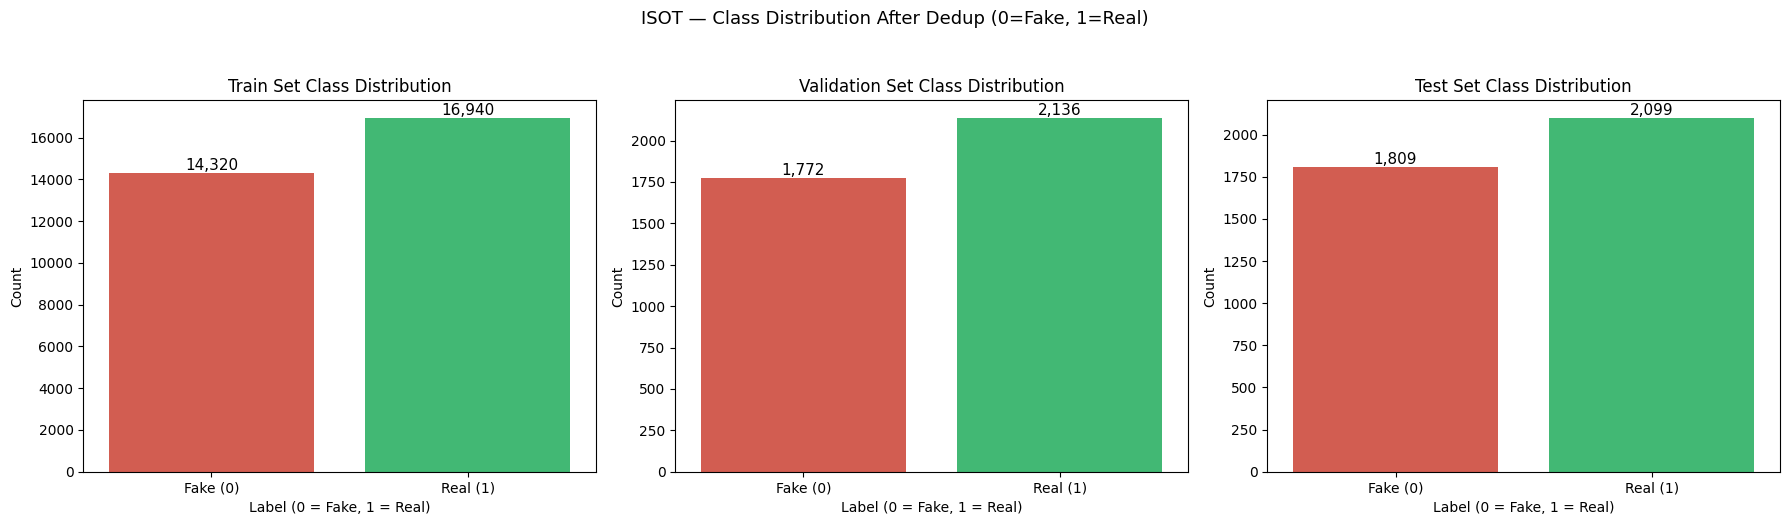

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(train_df, val_df, test_df, label_col):
    label_names = {0: "Fake (0)", 1: "Real (1)"}
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, df) in zip(axes, [("Train", train_df), ("Validation", val_df), ("Test", test_df)]):
        counts = df[label_col].value_counts().sort_index()
        sns.barplot(
            x=[label_names.get(l, str(l)) for l in counts.index],
            y=counts.values, ax=ax,
            palette=["#e74c3c", "#2ecc71"]  # red=Fake, green=Real
        )
        ax.set_title(f"{name} Set Class Distribution")
        ax.set_xlabel("Label (0 = Fake, 1 = Real)")
        ax.set_ylabel("Count")
        for p in ax.patches:
            ax.annotate(f"{int(p.get_height()):,}",
                        (p.get_x() + p.get_width() / 2, p.get_height()),
                        ha="center", va="bottom", fontsize=11)
    plt.suptitle("ISOT — Class Distribution After Dedup (0=Fake, 1=Real)", fontsize=13, y=1.04)
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_df, val_df, test_df, ISOT_CONFIG.label_col)

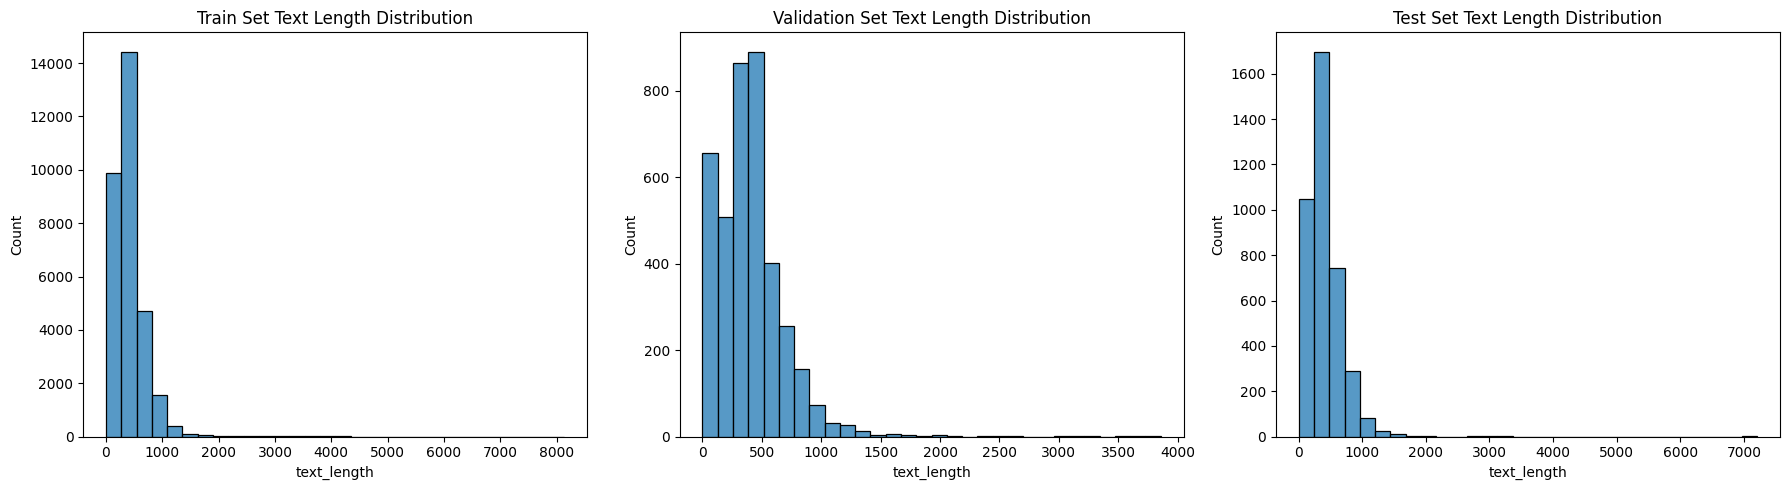

In [32]:
# Text length distribution (histogram) for all splits
def plot_text_length_distribution(train_df, val_df, test_df, text_col):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    train_df['text_length'] = train_df[text_col].apply(lambda x: len(str(x).split()))
    val_df['text_length'] = val_df[text_col].apply(lambda x: len(str(x).split()))
    test_df['text_length'] = test_df[text_col].apply(lambda x: len(str(x).split()))
    
    sns.histplot(train_df['text_length'], bins=30, ax=axes[0])
    axes[0].set_title("Train Set Text Length Distribution")
    
    sns.histplot(val_df['text_length'], bins=30, ax=axes[1])
    axes[1].set_title("Validation Set Text Length Distribution")
    
    sns.histplot(test_df['text_length'], bins=30, ax=axes[2])
    axes[2].set_title("Test Set Text Length Distribution")
    
    plt.tight_layout()
    plt.show()

plot_text_length_distribution(train_df, val_df, test_df, ISOT_CONFIG.text_col)

/tmp/ipykernel_37907/3190383732.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="label_name", y="text_length", data=df,


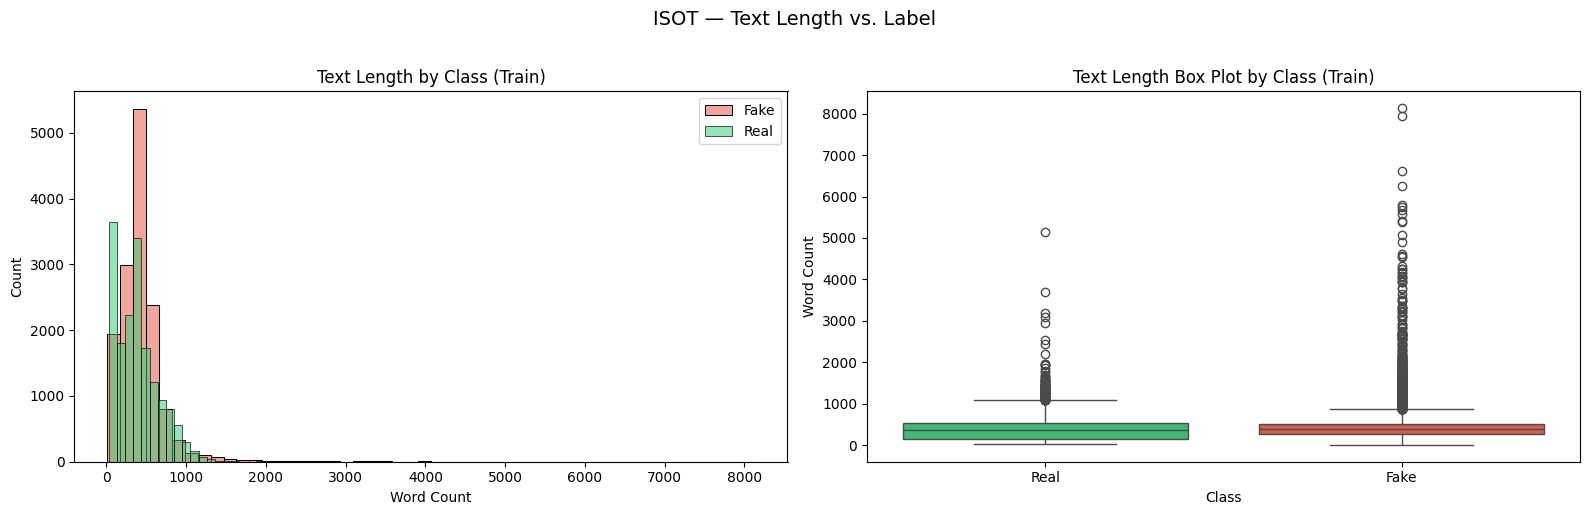

              count   mean    std   min    25%    50%    75%     max
label_name                                                          
Fake        14320.0  428.6  362.1   4.0  277.0  384.0  512.0  8135.0
Real        16940.0  393.2  273.0  28.0  157.0  367.0  531.0  5147.0


In [33]:
# Text length by class — are fake/real articles structurally different in length?
def plot_length_by_class(train_df, text_col, label_col):
    df = train_df.copy()
    df["text_length"] = df[text_col].apply(lambda x: len(str(x).split()))
    # ISOT: 0=Fake, 1=Real
    label_names = {0: "Fake", 1: "Real"}
    df["label_name"] = df[label_col].map(label_names)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Overlapping histograms
    for label, color in [(0, "#e74c3c"), (1, "#2ecc71")]:
        subset = df[df[label_col] == label]["text_length"]
        sns.histplot(subset, bins=50, ax=axes[0], color=color,
                     alpha=0.5, label=label_names[label])
    axes[0].set_title("Text Length by Class (Train)")
    axes[0].set_xlabel("Word Count")
    axes[0].legend()

    # Box plot
    sns.boxplot(x="label_name", y="text_length", data=df,
                palette={"Fake": "#e74c3c", "Real": "#2ecc71"}, ax=axes[1])
    axes[1].set_title("Text Length Box Plot by Class (Train)")
    axes[1].set_xlabel("Class")
    axes[1].set_ylabel("Word Count")

    plt.suptitle("ISOT — Text Length vs. Label", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(df.groupby("label_name")["text_length"].describe().round(1))

plot_length_by_class(train_df, ISOT_CONFIG.text_col, ISOT_CONFIG.label_col)

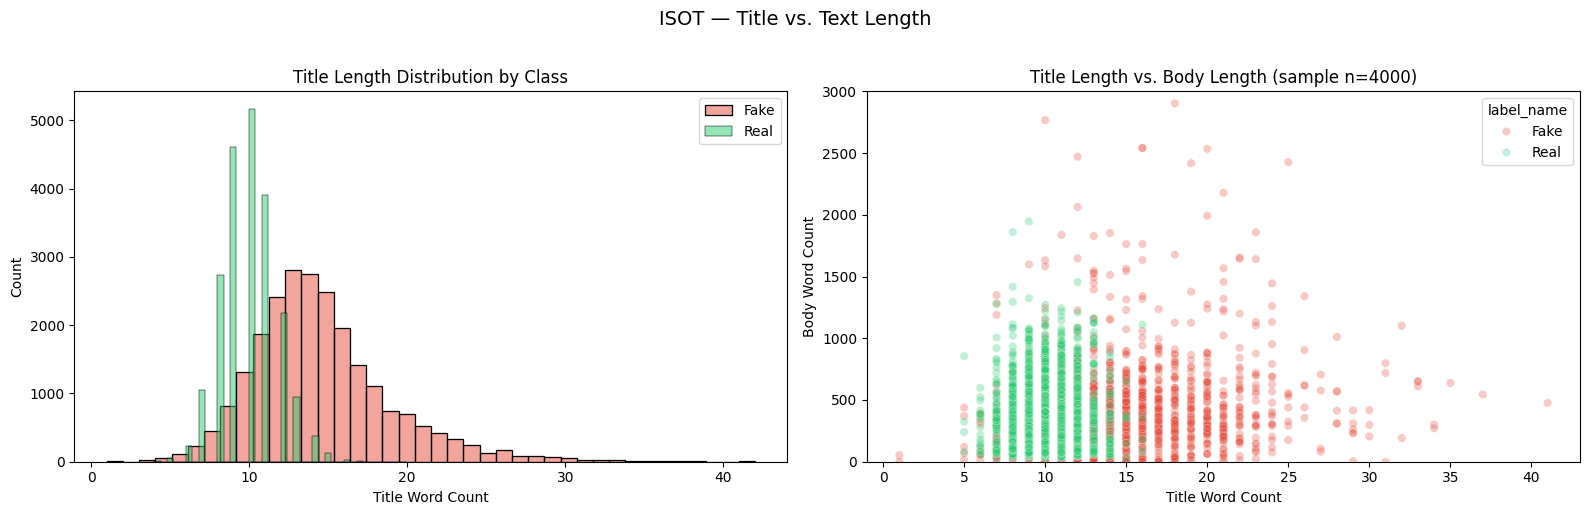

              count  mean  std  min   25%   50%   75%   max
label_name                                                 
Fake        23481.0  14.7  4.3  1.0  12.0  14.0  17.0  42.0
Real        21417.0  10.0  1.7  4.0   9.0  10.0  11.0  20.0


In [34]:
# Title vs text length correlation — do articles with longer titles have longer bodies?
def plot_title_text_correlation():
    import pandas as pd
    true_df = pd.read_csv(project_root / "data" / "raw" / "isot" / "True.csv")
    fake_df = pd.read_csv(project_root / "data" / "raw" / "isot" / "Fake.csv")
    true_df["label"] = 1
    fake_df["label"] = 0
    raw = pd.concat([true_df, fake_df], ignore_index=True).dropna(subset=["title", "text"])
    raw["title_len"] = raw["title"].apply(lambda x: len(str(x).split()))
    raw["text_len"]  = raw["text"].apply(lambda x: len(str(x).split()))
    # ISOT: 0=Fake, 1=Real
    label_names = {0: "Fake", 1: "Real"}
    raw["label_name"] = raw["label"].map(label_names)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Title length distribution by class
    for label, color in [(0, "#e74c3c"), (1, "#2ecc71")]:
        sns.histplot(raw[raw["label"] == label]["title_len"], bins=40,
                     ax=axes[0], color=color, alpha=0.5, label=label_names[label])
    axes[0].set_title("Title Length Distribution by Class")
    axes[0].set_xlabel("Title Word Count")
    axes[0].legend()

    # Scatter: title len vs body len (sample 2000 per class for readability)
    sample = raw.groupby("label").apply(lambda g: g.sample(min(2000, len(g)), random_state=42)).reset_index(drop=True)
    sns.scatterplot(x="title_len", y="text_len", hue="label_name",
                    data=sample, ax=axes[1], alpha=0.3,
                    palette={"Fake": "#e74c3c", "Real": "#2ecc71"})
    axes[1].set_title("Title Length vs. Body Length (sample n=4000)")
    axes[1].set_xlabel("Title Word Count")
    axes[1].set_ylabel("Body Word Count")
    axes[1].set_ylim(0, 3000)

    plt.suptitle("ISOT — Title vs. Text Length", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(raw.groupby("label_name")["title_len"].describe().round(1))

plot_title_text_correlation()

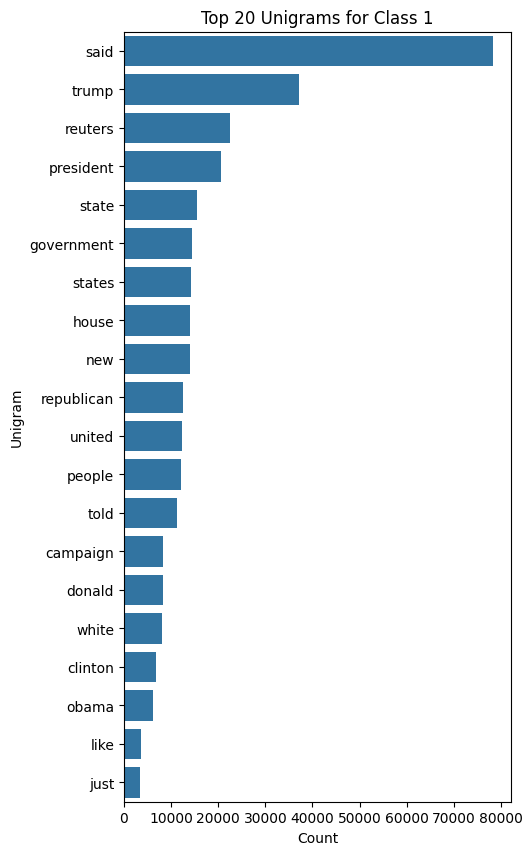

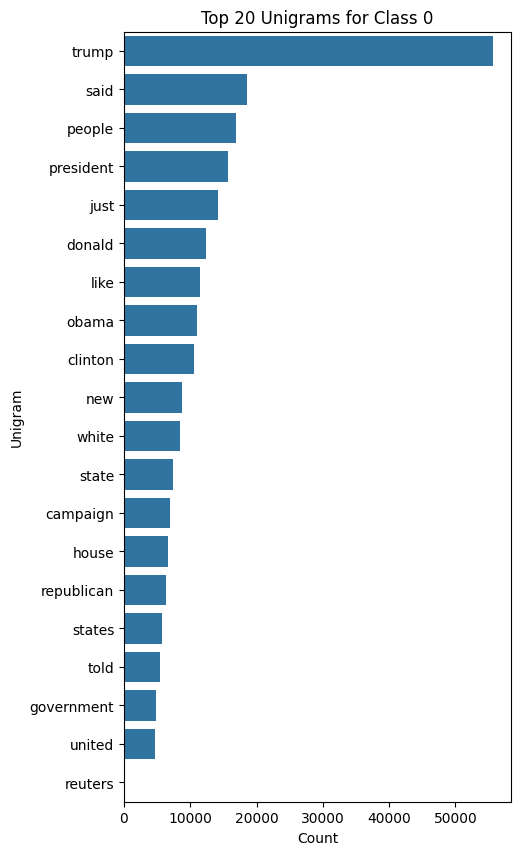

In [35]:
# Top 20 unigrams for each class in the training set
from sklearn.feature_extraction.text import CountVectorizer
def plot_top_unigrams(train_df, text_col, label_col):
    vectorizer = CountVectorizer(stop_words='english', max_features=20)
    X = vectorizer.fit_transform(train_df[text_col])
    feature_names = vectorizer.get_feature_names_out()
    
    for label in train_df[label_col].unique():
        label_mask = (train_df[label_col] == label).values
        label_X = X[label_mask]
        top_unigrams = label_X.sum(axis=0).A1
        top_indices = top_unigrams.argsort()[-20:][::-1]
        top_features = [feature_names[i] for i in top_indices]
        top_counts = top_unigrams[top_indices]
        
        plt.figure(figsize=(5, 10))
        sns.barplot(x=top_counts, y=top_features)
        plt.title(f"Top 20 Unigrams for Class {label}")
        plt.xlabel("Count")
        plt.ylabel("Unigram")
        plt.show()

plot_top_unigrams(train_df, ISOT_CONFIG.text_col, ISOT_CONFIG.label_col)

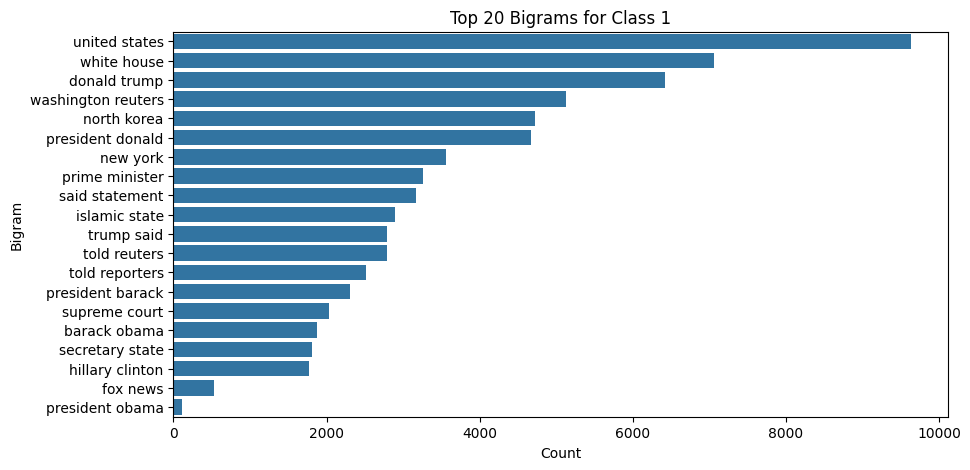

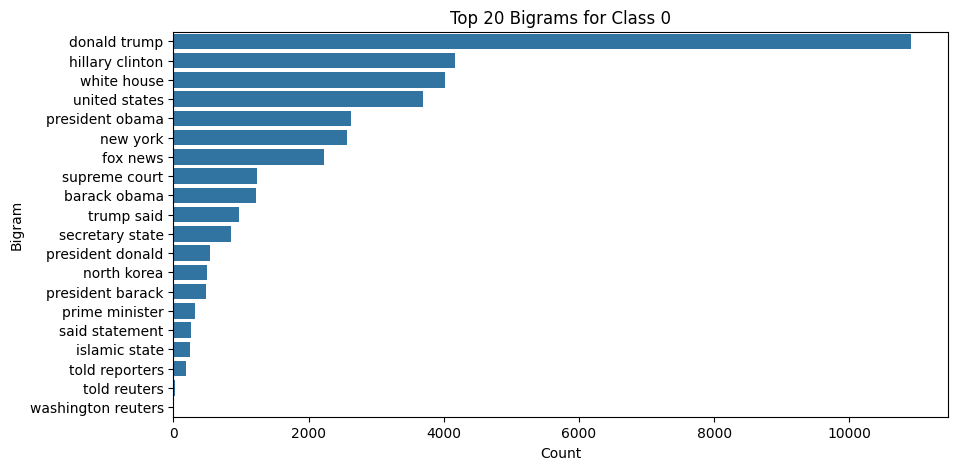

In [36]:
# Top 20 Bigrams for each class in the training set
def plot_top_bigrams(train_df, text_col, label_col):
    vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=20)
    X = vectorizer.fit_transform(train_df[text_col])
    feature_names = vectorizer.get_feature_names_out()
    
    for label in train_df[label_col].unique():
        label_mask = (train_df[label_col] == label).values
        label_X = X[label_mask]
        top_bigrams = label_X.sum(axis=0).A1
        top_indices = top_bigrams.argsort()[-20:][::-1]
        top_features = [feature_names[i] for i in top_indices]
        top_counts = top_bigrams[top_indices]
        
        plt.figure(figsize=(10, 5))
        sns.barplot(x=top_counts, y=top_features)
        plt.title(f"Top 20 Bigrams for Class {label}")
        plt.xlabel("Count")
        plt.ylabel("Bigram")
        plt.show()

plot_top_bigrams(train_df, ISOT_CONFIG.text_col, ISOT_CONFIG.label_col)

In [37]:
# Stats Summary table (mean/p95 length, vocab size, class balance)
def print_stats_summary(train_df, val_df, test_df, text_col, label_col):
    for split_name, df in zip(["Train", "Validation", "Test"], [train_df, val_df, test_df]):
        df['text_length'] = df[text_col].apply(lambda x: len(str(x).split()))
        mean_length = df['text_length'].mean()
        p95_length = df['text_length'].quantile(0.95)
        vocab_size = len(set(" ".join(df[text_col].dropna().astype(str)).split()))
        class_balance = df[label_col].value_counts(normalize=True)
        
        print(f"{split_name} Set:")
        print(f"Mean Text Length: {mean_length:.2f}")
        print(f"95th Percentile Text Length: {p95_length}")
        print(f"Vocabulary Size: {vocab_size}")
        print("Class Balance:")
        print(class_balance)
        print("\n")

print_stats_summary(train_df, val_df, test_df, ISOT_CONFIG.text_col, ISOT_CONFIG.label_col)

Train Set:
Mean Text Length: 409.41
95th Percentile Text Length: 888.0
Vocabulary Size: 197608
Class Balance:
label
1    0.541907
0    0.458093
Name: proportion, dtype: float64


Validation Set:
Mean Text Length: 406.05
95th Percentile Text Length: 872.0
Vocabulary Size: 57060
Class Balance:
label
1    0.546571
0    0.453429
Name: proportion, dtype: float64


Test Set:
Mean Text Length: 410.88
95th Percentile Text Length: 886.9499999999989
Vocabulary Size: 57122
Class Balance:
label
1    0.537103
0    0.462897
Name: proportion, dtype: float64


